# 40 — Adding **and** removing structure on one trajectory

**Where this sits (nb40 of nb38–41).** nb38 isolated removal, nb39 isolated addition. This notebook
shows **both on a single relational rollout**: as the regime-switching gravimetric data arrive, the
paradigm *gains* the couplings the relational mass-balance experiment wires into its precision
(structure **added**) and *sheds* the spurious directed edges the same evidence contradicts
(structure **removed**). We watch the Bayes net grow and prune on one trajectory.

**The setup.** We take the phlogiston paradigm with its directed belt edges *weakened to near-zero*
— so the agent's prior barely posits the calx↔mass↔gas coupling and the data must wire it in — and
*over-wire* it with three spurious edges whose sign the regime data contradict. One relational
rollout then drives:

* **ADD** — `gravimetric_H`'s mass-balance row deposits **off-diagonal** Fisher, so the belt
  couplings appear in the precision `Π` (the present-coupling count rises; the magnitude
  `|Π[calx, mass]|` climbs without bound);
* **REMOVE** — `bmr_prune_edge` retires the spurious directed edges the accumulated evidence
  decisively rejects (the same closed-form Savage–Dickey ΔF as nb38).

**The honest duality (reported).** A *persistent* edge prune needs the **relational** operator (its
off-diagonal Fisher keeps BMR sharp); a node **wake** needs the **node-wise** operator (the residual
lives in the prediction errors, and under relational observation the new coupling is directly
representable so the wake is *declined* — nb37 B4). One operator can't host both, so this trajectory
carries the two **edge** moves; the **node** add is nb39's, the **node** removal is nb38's §B.

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, jax, jax.numpy as jnp
import matplotlib.pyplot as plt
try:
    import networkx as nx
except Exception:
    nx = None
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

from src.structural.phlogiston import StructuralConfig, phlogiston_bn, gravimetric_H, phi_true_at
from src.structural.bayesnet import LinearGaussianBN
from src.structural import linalg, shells, plot

RESULTS = pathlib.Path(ROOT if (ROOT / 'results').exists() else ROOT.parent) / 'results' / 'structural_add_and_remove'
RESULTS.mkdir(parents=True, exist_ok=True)
cfg = StructuralConfig(t_shift=40, n_steps=120)
THR = 0.15; MARGIN = 0.3
bn = phlogiston_bn(cfg, conviction=2.0)
names = bn.names; idx = {n: i for i, n in enumerate(names)}; d = bn.dim

B = np.asarray(bn.B).copy()
for c, p in [('calx_heavier_than_metal', 'mass_change_sign'),
             ('calx_heavier_than_metal', 'gas_consumed')]:
    B[idx[c], idx[p]] = 0.04                       # weaken belt edges => the coupling must be LEARNED
spurious = [('calcination_releases', 'reduction_with_charcoal', 0.6),
            ('air_has_capacity', 'respiration_like_combustion', 0.6),
            ('combustion_releases', 'calx_heavier_than_metal', 0.5)]   # signs the regime data contradict
for p, c, w in spurious: B[idx[c], idx[p]] = w
over = LinearGaussianBN(B=jnp.asarray(B), b=bn.b, s=bn.s, names=names)
cpd_edges = [(names[u], names[v]) for v in range(d) for u in range(d) if abs(B[v, u]) > 1e-9]
spur_edges = [(p, c) for p, c, _ in spurious]
print(f'paradigm: weakened belt edges + {len(spur_edges)} spurious; {len(cpd_edges)} directed CPD edges total')

paradigm: weakened belt edges + 3 spurious; 13 directed CPD edges total


## Drawers (directed CPD net + undirected Π-coupling graph)

In [2]:
def dag_layout(net, seed=4):
    if nx is None:
        th = np.linspace(0, 2*np.pi, net.dim, endpoint=False)
        return {i: (np.cos(t), np.sin(t)) for i, t in enumerate(th)}
    G = nx.DiGraph(); G.add_nodes_from(range(net.dim)); Bm = np.asarray(net.B)
    for v in range(net.dim):
        for u in range(net.dim):
            if abs(Bm[v, u]) > 1e-9: G.add_edge(u, v)
    return nx.spring_layout(G, seed=seed, k=1.5)

def draw_dag(ax, net, pos, title, *, node_vals=None, removed=frozenset(), thr=0.05):
    Bm = np.asarray(net.B); nm = net.names; xy = np.array([pos[i] for i in range(net.dim)])
    for v in range(net.dim):
        for u in range(net.dim):
            e = (nm[u], nm[v]); present = abs(Bm[v, u]) > thr
            if not present and e not in removed: continue
            if e in removed: color, ls, lw, a = 'crimson', (0, (3, 2)), 2.2, 0.9
            else:            color, ls, lw, a = '0.6', '-', 1.0 + 2.0*min(abs(Bm[v, u]), 1.0), 0.7
            ax.annotate('', xy=xy[v], xytext=xy[u],
                        arrowprops=dict(arrowstyle='-|>', color=color, lw=lw, ls=ls, alpha=a, shrinkA=11, shrinkB=11))
    vals = np.zeros(net.dim) if node_vals is None else np.asarray(node_vals)
    sc = ax.scatter(xy[:,0], xy[:,1], c=vals, cmap='coolwarm', s=420, vmin=-1.5, vmax=1.5, edgecolor='k', lw=0.6, zorder=3)
    for i, n in enumerate(nm):
        ax.text(xy[i,0], xy[i,1]-0.13, n[:11]+('…' if len(n) > 12 else ''), ha='center', va='top', fontsize=6, zorder=4)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal'); ax.margins(0.16)
    return sc

def draw_couplings(ax, Pi, pos, title, *, highlight=frozenset(), thr=THR):
    P = np.abs(np.asarray(Pi)).copy(); np.fill_diagonal(P, 0.0); xy = np.array([pos[i] for i in range(d)])
    for a in range(d):
        for b in range(a+1, d):
            if P[a, b] > thr:
                hot = (names[a], names[b]) in highlight or (names[b], names[a]) in highlight
                ax.plot([xy[a,0], xy[b,0]], [xy[a,1], xy[b,1]], color='seagreen' if hot else '0.65',
                        lw=(2.6 if hot else 0.9) + 1.2*min(P[a,b], 1.0), alpha=0.9 if hot else 0.45, zorder=1)
    ax.scatter(xy[:,0], xy[:,1], c='#d8d8d8', s=420, edgecolor='k', lw=0.6, zorder=3)
    for i, n in enumerate(names):
        ax.text(xy[i,0], xy[i,1]-0.13, n[:11]+('…' if len(n) > 12 else ''), ha='center', va='top', fontsize=6, zorder=4)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal'); ax.margins(0.16)

## A — The trajectory: accrete the relational evidence, track both moves

At each step we deposit the gravimetric Fisher and record (i) the count of couplings present in `Π`
(the **added** structure, `shells.edge_count_trace` — the same read-out as nb36) and (ii) which
spurious directed edges BMR decisively prunes (the **removed** structure). We keep every `Π`
snapshot so we can render the net later.

In [3]:
Hg = gravimetric_H(cfg); gbn = over.to_info(); Pi = gbn.Pi; h = gbn.h; key = jax.random.PRNGKey(1)
Pis = []; pruned_count_t = []; belt_mag_t = []; spur_dF_t = {e: [] for e in spur_edges}
belt_dF_t = []
ci, mi = idx['calx_heavier_than_metal'], idx['mass_change_sign']
for t in range(cfg.n_steps):
    phi = phi_true_at(cfg, t); key, k = jax.random.split(key)
    o = Hg @ phi + 0.1 * jax.random.normal(k, (Hg.shape[0],))
    Jd, jd = linalg.fisher_deposit(Hg, o, cfg.sigma_o); Pi = Pi + Jd; h = h + jd
    Pis.append(np.asarray(Pi)); belt_mag_t.append(float(np.abs(np.asarray(Pi))[ci, mi]))
    lik = (Pi - gbn.Pi, h - gbn.h)
    npr = 0
    for (p, c) in spur_edges:
        dF = float(over.bmr_prune_edge(c, p, likelihood=lik)['delta_F'])
        spur_dF_t[(p, c)].append(dF); npr += int(dF > MARGIN)
    pruned_count_t.append(npr)
    belt_dF_t.append(float(over.bmr_prune_edge('calx_heavier_than_metal', 'mass_change_sign', likelihood=lik)['delta_F']))

present_t, _ = shells.edge_count_trace(np.stack(Pis), threshold=THR)
prior_present = int((np.abs(np.asarray(gbn.Pi))[np.triu_indices(d, 1)] > THR).sum())
present_t = np.concatenate([[prior_present], present_t])
committed_t = len(cpd_edges) - np.concatenate([[0], np.array(pruned_count_t)])
print(f'ADD:    Π-present couplings {prior_present} (prior) -> {int(present_t[-1])} (end)  '
      f'[belt block wired in; |Π[calx,mass]| {belt_mag_t[0]:.2f} -> {belt_mag_t[-1]:.1f}]')
print(f'REMOVE: committed directed edges {len(cpd_edges)} -> {int(committed_t[-1])}  '
      f'[{int(pruned_count_t[-1])}/{len(spur_edges)} spurious retired by BMR]')

ADD:    Π-present couplings 11 (prior) -> 14 (end)  [belt block wired in; |Π[calx,mass]| 1.08 -> 120.1]
REMOVE: committed directed edges 13 -> 10  [3/3 spurious retired by BMR]


### A1 — Both moves on one timeline

Green (left axis): the couplings the data **add** to the precision. Red (right axis): the directed
edges BMR **removes**. The regime shift at `t_shift` is marked. One trajectory carries an expansion
of the precision *and* a reduction of the directed structure.

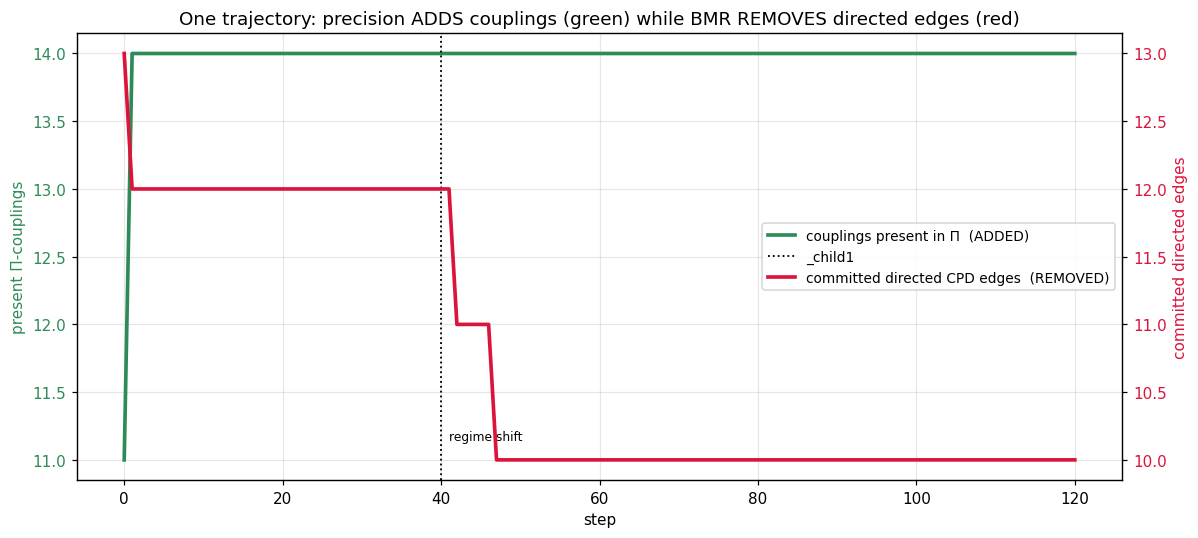

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(present_t))
ax.plot(x, present_t, color='seagreen', lw=2.4, label='couplings present in Π  (ADDED)')
ax.set_xlabel('step'); ax.set_ylabel('present Π-couplings', color='seagreen')
ax.tick_params(axis='y', labelcolor='seagreen')
ax.axvline(cfg.t_shift, color='k', ls=':', lw=1.2); ax.text(cfg.t_shift+1, ax.get_ylim()[0]+0.3, 'regime shift', fontsize=8)
ax2 = ax.twinx()
ax2.plot(x, committed_t, color='crimson', lw=2.4, label='committed directed CPD edges  (REMOVED)')
ax2.set_ylabel('committed directed edges', color='crimson'); ax2.tick_params(axis='y', labelcolor='crimson')
ax2.grid(False)
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc='center right', fontsize=9)
ax.set_title('One trajectory: precision ADDS couplings (green) while BMR REMOVES directed edges (red)')
plt.tight_layout(); plt.savefig(RESULTS / 'A1_add_and_remove_timeline.png'); plt.show()

### A2 — The directed Bayes net being pruned (three snapshots)

The committed directed CPD net at the start, the regime shift, and the end. Edges BMR has retired
by each time are drawn red-dashed where they were. The spurious couplings (the regime data
contradict their sign) are shed.

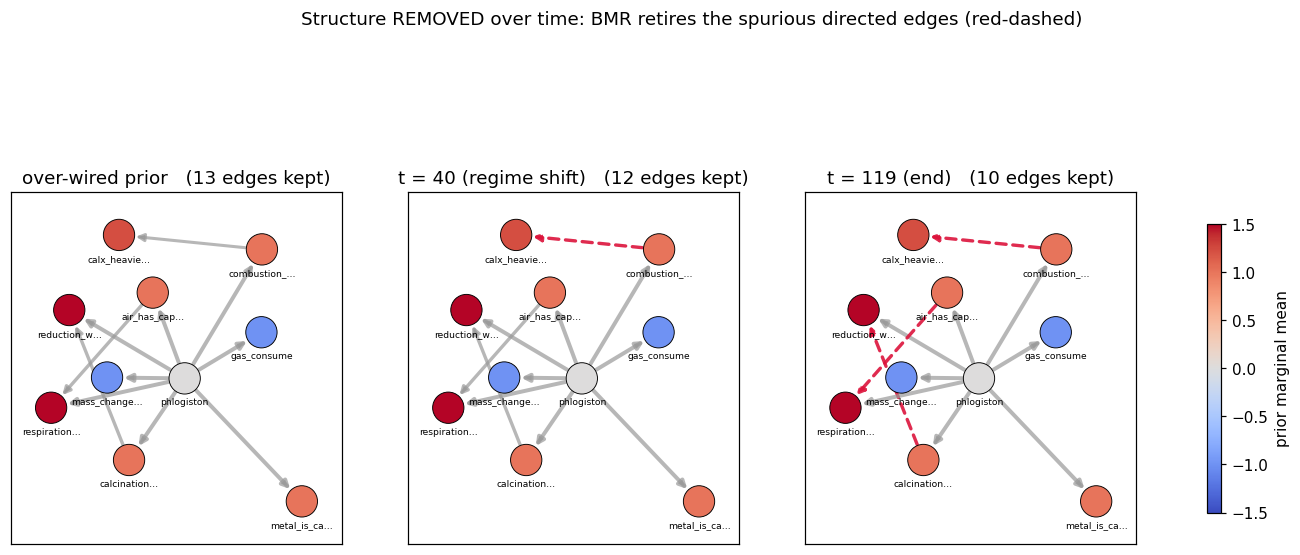

In [5]:
def committed_at(step):
    # which spurious edges BMR has decisively pruned by this step (reuse the per-step ΔF trace)
    return {(p, c) for (p, c) in spur_edges if spur_dF_t[(p, c)][step] > MARGIN}
snaps = [('over-wired prior', frozenset()),
         (f't = {cfg.t_shift} (regime shift)', committed_at(cfg.t_shift)),
         (f't = {cfg.n_steps-1} (end)', committed_at(cfg.n_steps - 1))]
pos = dag_layout(over, seed=4); mu_prior = np.asarray(over.joint()[0])
fig, axs = plt.subplots(1, 3, figsize=(16.5, 6.2))
for ax, (label, rem) in zip(axs, snaps):
    sc = draw_dag(ax, over, pos, f'{label}   ({len(cpd_edges)-len(rem)} edges kept)',
                  node_vals=mu_prior, removed=rem)
fig.suptitle('Structure REMOVED over time: BMR retires the spurious directed edges (red-dashed)', y=1.02)
fig.colorbar(sc, ax=axs, shrink=0.55, label='prior marginal mean')
plt.savefig(RESULTS / 'A2_directed_net_pruning.png', bbox_inches='tight'); plt.show()

## B — The precision gaining the belt block (the ADD, as a coupling graph)

The undirected coupling view of `Π`: before any data the belt nodes are only weakly linked
(the prior's near-zero belt edges); the relational mass-balance experiment wires the
`calx ↔ mass_change ↔ gas` block firmly in. Green = the belt couplings the data added.

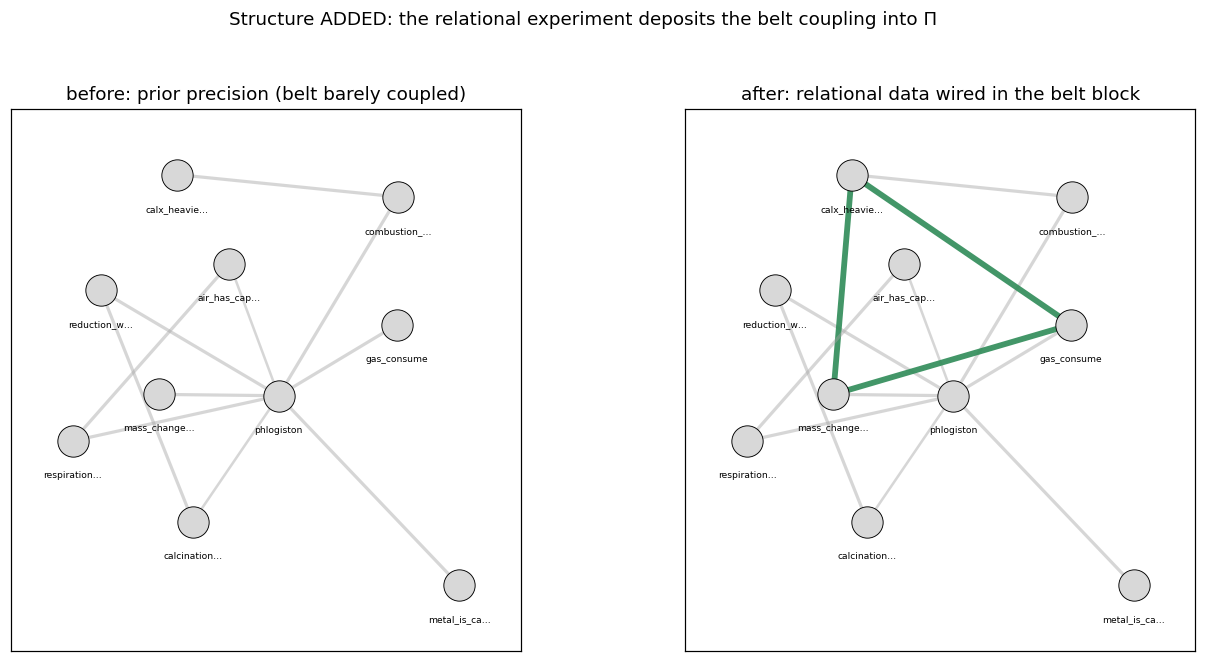

belt couplings present in Π: 0 (prior) -> 3 (after)


In [6]:
belt_pairs = {('calx_heavier_than_metal', 'mass_change_sign'),
              ('calx_heavier_than_metal', 'gas_consumed'),
              ('mass_change_sign', 'gas_consumed')}
fig, axs = plt.subplots(1, 2, figsize=(14.5, 6.4))
draw_couplings(axs[0], gbn.Pi, pos, 'before: prior precision (belt barely coupled)', highlight=belt_pairs)
draw_couplings(axs[1], Pis[-1], pos, 'after: relational data wired in the belt block', highlight=belt_pairs)
fig.suptitle('Structure ADDED: the relational experiment deposits the belt coupling into Π', y=1.02)
plt.savefig(RESULTS / 'B_precision_belt_block_added.png', bbox_inches='tight'); plt.show()
print('belt couplings present in Π:',
      sum(1 for a, b in belt_pairs if np.abs(np.asarray(gbn.Pi))[idx[a], idx[b]] > THR), '(prior) ->',
      sum(1 for a, b in belt_pairs if np.abs(Pis[-1])[idx[a], idx[b]] > THR), '(after)')

## C — The two signals, and the honest duality

The concrete add and remove curves: `|Π[calx, mass]|` climbing (the coupling the data wire in) and a
spurious edge's BMR ΔF rising past the prune margin (the edge the data retire). The note beneath is
the identifiability duality this trajectory ran into.

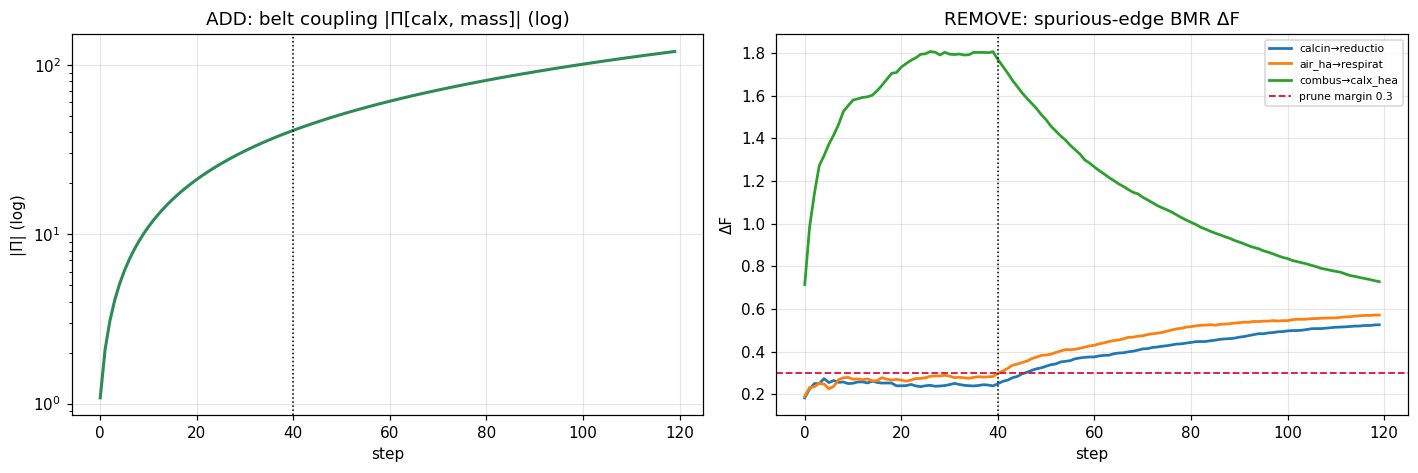

In [7]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.4))
a0.plot(belt_mag_t, color='seagreen', lw=2); a0.set_yscale('log')
a0.axvline(cfg.t_shift, color='k', ls=':', lw=1)
a0.set_title('ADD: belt coupling |Π[calx, mass]| (log)'); a0.set_xlabel('step'); a0.set_ylabel('|Π| (log)')
for (p, c), dF in spur_dF_t.items():
    a1.plot(dF, lw=1.8, label=f'{p[:6]}→{c[:8]}')
a1.axhline(MARGIN, color='crimson', ls='--', lw=1.2, label=f'prune margin {MARGIN}')
a1.axvline(cfg.t_shift, color='k', ls=':', lw=1)
a1.set_title('REMOVE: spurious-edge BMR ΔF'); a1.set_xlabel('step'); a1.set_ylabel('ΔF'); a1.legend(fontsize=7)
plt.tight_layout(); plt.savefig(RESULTS / 'C_add_remove_signals.png'); plt.show()

**The duality, stated plainly.** This trajectory carries the two *edge* moves because the
observation operator is **relational**: its off-diagonal Fisher keeps Bayesian Model Reduction
discriminating, so a prune *persists* as data accumulate. A node **wake** is the opposite case — its
trigger is read from the prediction **errors** (node-wise observation, where `Π` stays diagonal), and
under a relational channel that spans the same nodes the new coupling becomes *directly
representable*, so the wake is **declined** (nb37 B4). The two moves prefer opposite operators; no
single channel hosts both a node-add and a persistent `Π`-edge prune. The node-add lives in nb39
(node-wise residual → wake), the node-removal in nb38 §B (marginalize the hub).

## Verdict

Both faces of structure learning on **one** relational trajectory, on the existing classes:

* **ADD** — the gravimetric mass-balance experiment deposits off-diagonal Fisher, so the
  `calx ↔ mass ↔ gas` belt block the prior barely posited is wired into `Π`: the present-coupling
  count rises and `|Π[calx, mass]|` climbs without bound (§A1, §B);
* **REMOVE** — `bmr_prune_edge` retires the spurious directed edges the regime data contradict, the
  closed-form Savage–Dickey reduction of nb38, here unfolding along the same run (§A1, §A2, §C);
* the **honest duality** — a persistent edge prune wants the relational operator, a node wake wants
  the node-wise one; the two structure moves prefer opposite channels, which is the paper's S6
  bubble-vs-echo (a missing channel vs a silenced one) read at the level of structure learning.

Next (nb41): hold the world fixed and vary the **starting net** — how the initialization decides
which couplings get added and which removed.